In [3]:
!pip -q install ultralytics opencv-python pyyaml

In [2]:
from pathlib import Path

MFSD_ROOT = Path("MSFD/1")
IMAGES_DIR = MFSD_ROOT / "face_crop"
MASKS_DIR  = MFSD_ROOT / "face_crop_segmentation"

OUT_ROOT = Path("mfsd_yolo")
YAML_PATH = Path("mfsd.yaml")

print("Images:", IMAGES_DIR, IMAGES_DIR.exists())
print("Masks: ", MASKS_DIR, MASKS_DIR.exists())

Images: MSFD/1/face_crop True
Masks:  MSFD/1/face_crop_segmentation True


In [8]:
import random, shutil
import cv2
import numpy as np
import yaml

VAL_FRAC = 0.05
SEED = 42

CLASS_ID = 0
CLASS_NAME = "mask"

MIN_AREA = 150
EPS_REL = 0.002

def list_images(folder: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in exts])

def find_mask_for_image(img_path: Path, masks_dir: Path):
    stem = img_path.stem
    for ext in [".png", ".jpg", ".jpeg", ".bmp"]:
        p = masks_dir / f"{stem}{ext}"
        if p.exists():
            return p
    return None

def mask_to_polygons(mask_u8: np.ndarray, min_area: int = 50, eps_rel: float = 0.002):
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        eps = eps_rel * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, eps, True)
        if approx is None or len(approx) < 3:
            continue
        polys.append(approx[:, 0, :])
    return polys

def write_yolo_seg_label(txt_path: Path, polys, w: int, h: int, class_id: int = 0):
    lines = []
    for poly in polys:
        coords = []
        for x, y in poly:
            coords.append(f"{x / w:.6f}")
            coords.append(f"{y / h:.6f}")
        lines.append(str(class_id) + " " + " ".join(coords))
    txt_path.parent.mkdir(parents=True, exist_ok=True)
    txt_path.write_text("\n".join(lines), encoding="utf-8")

def prepare_out_dirs(out_root: Path):
    for split in ["train", "val"]:
        (out_root / "images" / split).mkdir(parents=True, exist_ok=True)
        (out_root / "labels" / split).mkdir(parents=True, exist_ok=True)

imgs = list_images(IMAGES_DIR)
pairs = []
missing = 0
for img_path in imgs:
    mask_path = find_mask_for_image(img_path, MASKS_DIR)
    if mask_path is None:
        missing += 1
        continue
    pairs.append((img_path, mask_path))

print(f"Нашёл изображений: {len(imgs)}")
print(f"Пар image-mask:   {len(pairs)}")
print(f"Без маски:        {missing}")

random.seed(SEED)
random.shuffle(pairs)
n_val = int(len(pairs) * VAL_FRAC)
val_pairs = pairs[:n_val]
train_pairs = pairs[n_val:]
print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)}")

if OUT_ROOT.exists():
    shutil.rmtree(OUT_ROOT)
prepare_out_dirs(OUT_ROOT)

def process_split(split_name: str, split_pairs):
    out_img_dir = OUT_ROOT / "images" / split_name
    out_lbl_dir = OUT_ROOT / "labels" / split_name

    for img_path, mask_path in split_pairs:
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue

        mask_bin = (mask > 127).astype(np.uint8) * 255
        polys = mask_to_polygons(mask_bin, min_area=MIN_AREA, eps_rel=EPS_REL)

        label_path = out_lbl_dir / f"{img_path.stem}.txt"
        if polys:
            write_yolo_seg_label(label_path, polys, w=w, h=h, class_id=CLASS_ID)
        else:
            label_path.write_text("", encoding="utf-8")

        shutil.copy2(img_path, out_img_dir / img_path.name)

process_split("train", train_pairs)
process_split("val", val_pairs)

data_yaml = {
    "path": str(OUT_ROOT.resolve()),
    "train": "images/train",
    "val": "images/val",
    "names": {CLASS_ID: CLASS_NAME},
}
YAML_PATH.write_text(yaml.safe_dump(data_yaml, sort_keys=False, allow_unicode=True), encoding="utf-8")

print("Готово:", OUT_ROOT.resolve())
print("YAML:", YAML_PATH.resolve())


Нашёл изображений: 9383
Пар image-mask:   9382
Без маски:        1
Train: 8913 | Val: 469
Готово: /Users/danilagalkin/OI/dop/mfsd_yolo
YAML: /Users/danilagalkin/OI/dop/mfsd.yaml


In [9]:
import os, random
from pathlib import Path

lbls = list((OUT_ROOT/"labels/train").glob("*.txt"))
print("labels train:", len(lbls))

sample = random.choice(lbls)
print("sample label:", sample.name)
print(sample.read_text()[:300])


labels train: 8913
sample label: 007878_1.txt
0 0.176000 0.447552 0.176000 0.482517 0.184000 0.489510 0.184000 0.573427 0.176000 0.580420 0.176000 0.601399 0.168000 0.608392 0.168000 0.643357 0.160000 0.650350 0.160000 0.671329 0.168000 0.685315 0.200000 0.706294 0.232000 0.762238 0.256000 0.783217 0.256000 0.790210 0.368000 0.895105 0.376000 0


In [10]:
import torch
print("mps available:", torch.backends.mps.is_available())
print("mps built:", torch.backends.mps.is_built())


mps available: True
mps built: True


In [1]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"


In [6]:
from ultralytics import YOLO

In [11]:
model = YOLO("yolov8n-seg.pt")
results = model.train(
    data="mfsd.yaml",
    imgsz=320,
    epochs=1,
    batch=4,
    device="mps",
    workers=2,
    cache="disk",     
    amp=False,
    val=False,
    fraction=0.001,
    freeze=10,
    optimizer="AdamW",
    lr0=0.008,
    lrf=0.01,
    warmup_epochs=0.5,
    erasing=0.0,
    close_mosaic=1,
    plots=False,
    save=True,
)


Ultralytics 8.3.240 🚀 Python-3.12.11 torch-2.2.2 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=1, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=mfsd.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.0, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.001, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.008, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train13, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0, plots=False, pose=12.0, pretrained=True, profile

/Users/danilagalkin/OI/.venv/lib/python3.12/site-packages/polars/_cpu_check.py:250: RuntimeWarning: Missing required CPU features.

The following required CPU features were not detected:
    avx, avx2, fma, bmi1, bmi2, lzcnt, movbe
Continuing to use this version of Polars on this processor will likely result in a crash.
Install `polars[rtcompat]` instead of `polars` to run Polars with better compatibility.

Hint: If you are on an Apple ARM machine (e.g. M1) this is likely due to running Python under Rosetta.
It is recommended to install a native version of Python that does not run under Rosetta x86-64 emulation.

If you believe this warning to be a false positive, you can set the `POLARS_SKIP_CPU_CHECK` environment variable to bypass this check.

  warnings.warn(



1 epochs completed in 0.032 hours.
Optimizer stripped from /opt/homebrew/runs/segment/train13/weights/last.pt, 6.7MB
Optimizer stripped from /opt/homebrew/runs/segment/train13/weights/best.pt, 6.7MB

Validating /opt/homebrew/runs/segment/train13/weights/best.pt...
Ultralytics 8.3.240 🚀 Python-3.12.11 torch-2.2.2 MPS (Apple M4 Pro)
YOLOv8n-seg summary (fused): 85 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 2.0it/s 28.9s0.4ss
                   all        469        470    0.00628      0.987      0.877      0.528    0.00591       0.93      0.539      0.199
Speed: 0.5ms preprocess, 24.8ms inference, 0.0ms loss, 20.6ms postprocess per image


In [12]:
model = YOLO("yolov8n-seg.pt")
results = model.train(
    data="mfsd.yaml",
    imgsz=320,
    epochs=2,
    batch=4,
    device="mps",
    workers=2,
    cache="disk",     
    amp=False,
    val=False,
    fraction=0.5,
    freeze=10,
    optimizer="AdamW",
    lr0=0.008,
    lrf=0.01,
    warmup_epochs=0.5,
    erasing=0.0,
    close_mosaic=1,
    plots=False,
    save=True,
    project="runs",  
    name="mfsd_run_final",
)


Ultralytics 8.3.240 🚀 Python-3.12.11 torch-2.2.2 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=False, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=1, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=mfsd.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2, erasing=0.0, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.5, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.008, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=mfsd_run_final, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0, plots=False, pose=12.0, pretrained=True, pr

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv("runs/mfsd_run_final/results.csv")
df.tail()

,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),...,metrics/recall(M),metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,1281.95,0.95681,1.50249,0.77019,1.09743,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00800,0.00800,0.00800
1,2,2643.94,0.63549,1.07289,0.44857,0.98018,0.97332,0.93142,0.95262,0.81266,...,0.93355,0.95275,0.83859,0.65929,0.14581,0.83374,0.5848,0.00404,0.00404,0.00404


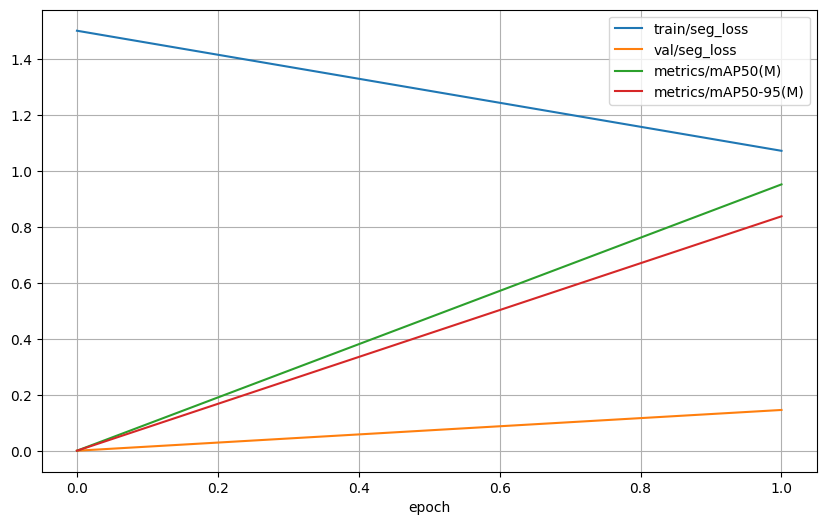

In [24]:
metrics = [
    "train/seg_loss",
    "val/seg_loss",
    "metrics/mAP50(M)",
    "metrics/mAP50-95(M)",
]

plt.figure(figsize=(10, 6))
for m in metrics:
    if m in df.columns:
        plt.plot(df[m], label=m)

plt.xlabel("epoch")
plt.legend()
plt.grid(True)
plt.show()


In [20]:
from ultralytics import YOLO

weights = run_dir / "weights" / "best.pt"
model = YOLO(str(weights))

val_res = model.val(data="mfsd.yaml", split="val", imgsz=320, device="mps")
val_res

Ultralytics 8.3.240 🚀 Python-3.12.11 torch-2.2.2 MPS (Apple M4 Pro)
YOLOv8n-seg summary (fused): 85 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 320.9±227.2 MB/s, size: 94.0 KB)
val: Scanning /Users/danilagalkin/OI/dop/mfsd_yolo/labels/val.cache... 469 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 469/469 654.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 2.1s/it 1:030.4sss
                   all        469        470      0.987      0.959      0.984      0.835      0.976       0.97      0.983      0.863
Speed: 6.9ms preprocess, 76.8ms inference, 0.0ms loss, 12.6ms postprocess per image
Results saved to /opt/homebrew/runs/segment/val


ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x1b6ab7980>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    


0: 320x320 1 mask, 1273.2ms
1: 320x320 1 mask, 1273.2ms
2: 320x320 1 mask, 1273.2ms
3: 320x320 1 mask, 1273.2ms
4: 320x320 1 mask, 1273.2ms
5: 320x320 1 mask, 1273.2ms
Speed: 201.1ms preprocess, 1273.2ms inference, 416.1ms postprocess per image at shape (1, 3, 320, 320)


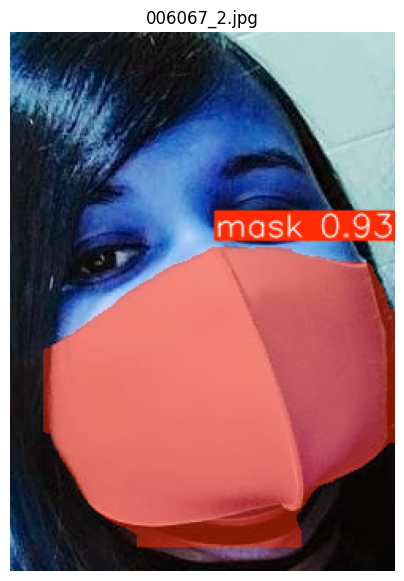

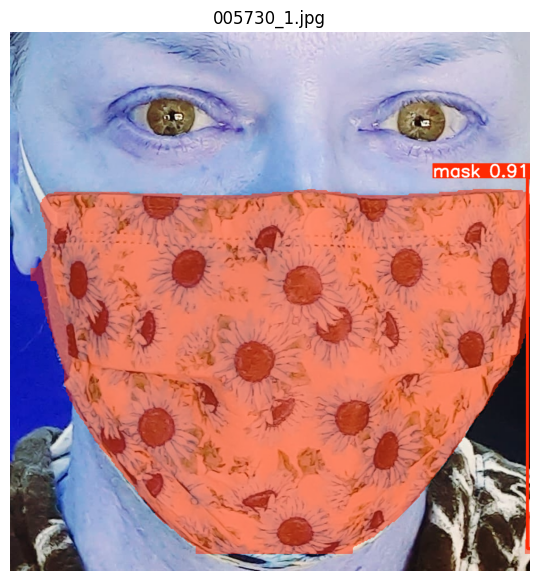

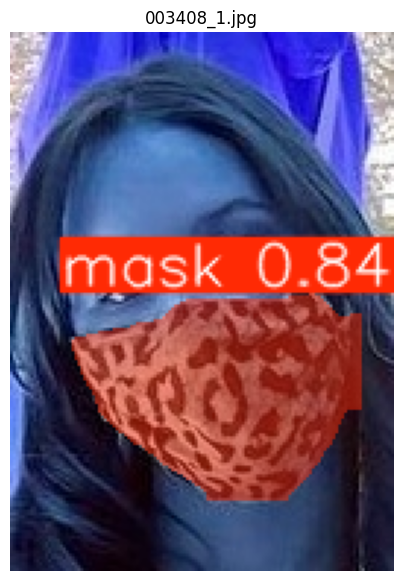

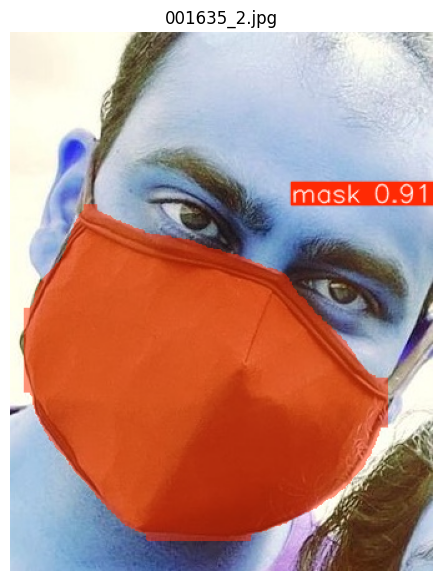

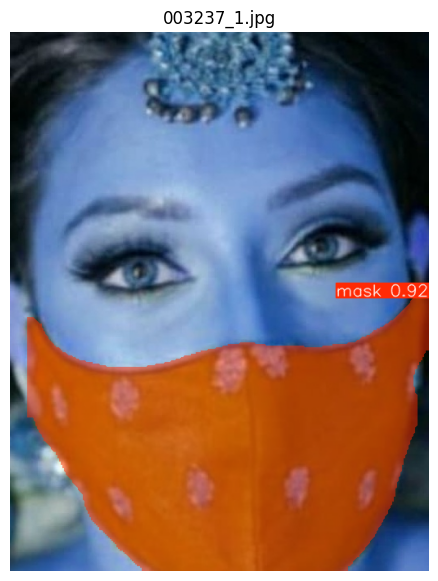

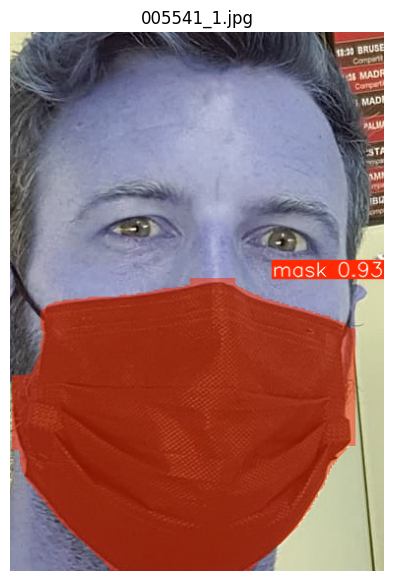

In [21]:
from pathlib import Path
import random
import matplotlib.pyplot as plt

val_images_dir = Path("mfsd_yolo/images/val") 
imgs = sorted([p for p in val_images_dir.iterdir() if p.suffix.lower() in [".jpg",".jpeg",".png",".bmp",".webp"]])

sample = random.sample(imgs, k=min(6, len(imgs)))
preds = model.predict(source=[str(p) for p in sample], imgsz=320, device="mps", conf=0.25)

for pth, r in zip(sample, preds):
    im = r.plot()  
    plt.figure(figsize=(7,7))
    plt.imshow(im)
    plt.title(pth.name)
    plt.axis("off")
    plt.show()
